# Credit Card Fraud Detection using Machine Learning

## Objective
The goal of this project is to detect fraudulent credit card transactions using machine learning models. Since fraud cases are extremely rare compared to genuine transactions, the project focuses on handling imbalanced data using SMOTE and comparing different classification models.

**Models Used:**
- Logistic Regression
- Random Forest
- XGBoost

**Evaluation Metrics:**
- Precision
- Recall
- F1-Score
- Confusion Matrix

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys

print(sys.executable)

c:\Users\DELL\OneDrive\Documents\Credit_Card_Fraud_Detection\venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything is working! 🚀")

Everything is working! 🚀


In [4]:
import pandas as pd

df = pd.read_csv("../dataset/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


In [6]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1081


In [11]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [12]:
fraud_percentage = (df["Class"].value_counts()[1] / len(df)) * 100
print(f"Fraud Transactions: {fraud_percentage:.4f}%")

Fraud Transactions: 0.1727%


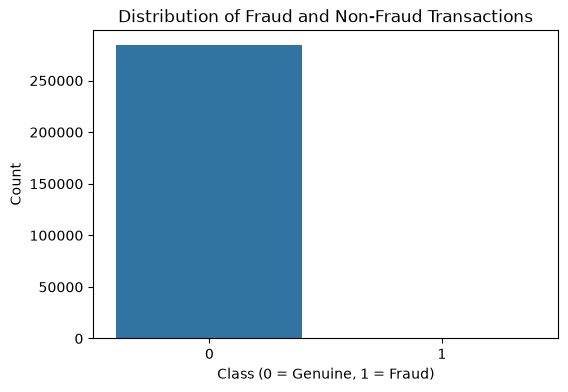

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Fraud and Non-Fraud Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

In [14]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [15]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


### Observation

The dataset is highly imbalanced.

- Genuine Transactions (Class 0): **284,315 (99.83%)**
- Fraudulent Transactions (Class 1): **492 (0.17%)**

Such an imbalance can cause machine learning models to become biased toward the majority class. To address this issue, SMOTE (Synthetic Minority Oversampling Technique) will be applied later to balance the training data before model training.

In [16]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [17]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1081


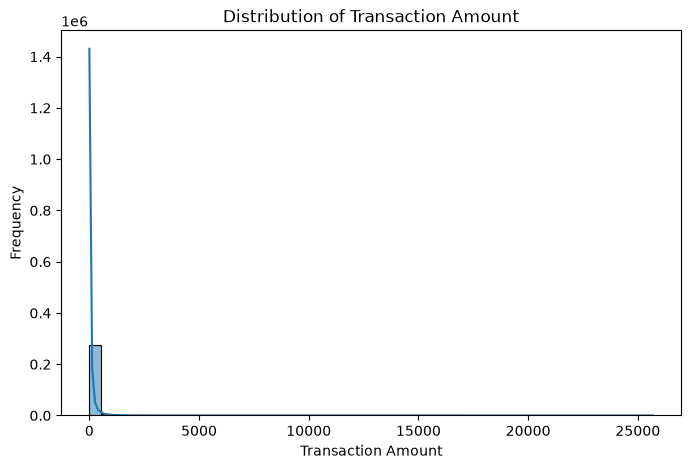

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

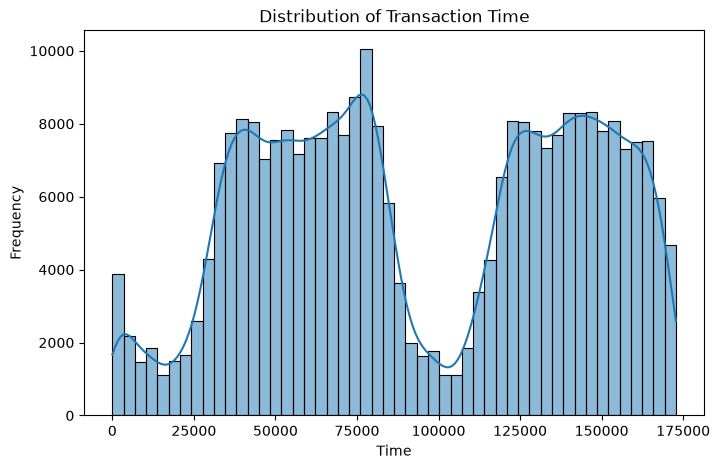

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["Time"], bins=50, kde=True)
plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

In [20]:
# Remove duplicate rows
df = df.drop_duplicates()

# Verify
print("Duplicate Rows After Removal:", df.duplicated().sum())

Duplicate Rows After Removal: 0


In [21]:
print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (283726, 31)


### Duplicate Records

The dataset contained **1,081 duplicate rows**, which were removed during preprocessing to improve data quality and prevent duplicate transactions from influencing the machine learning models.

After removing duplicates, the dataset contains **283,726 transactions**.

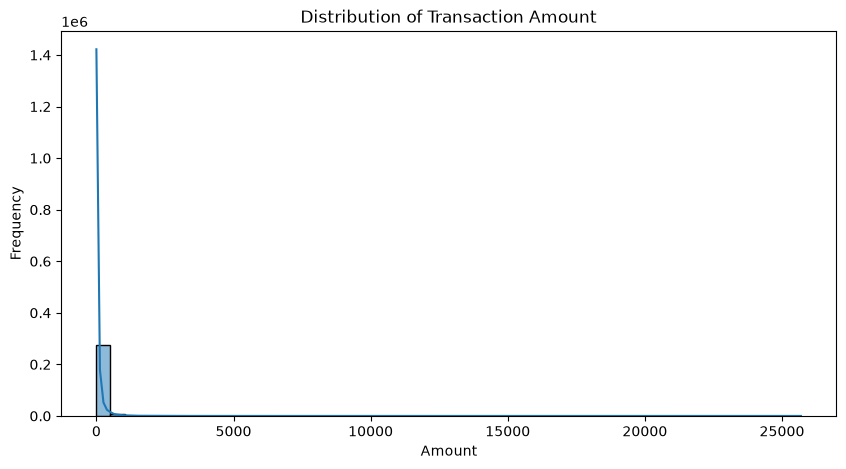

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

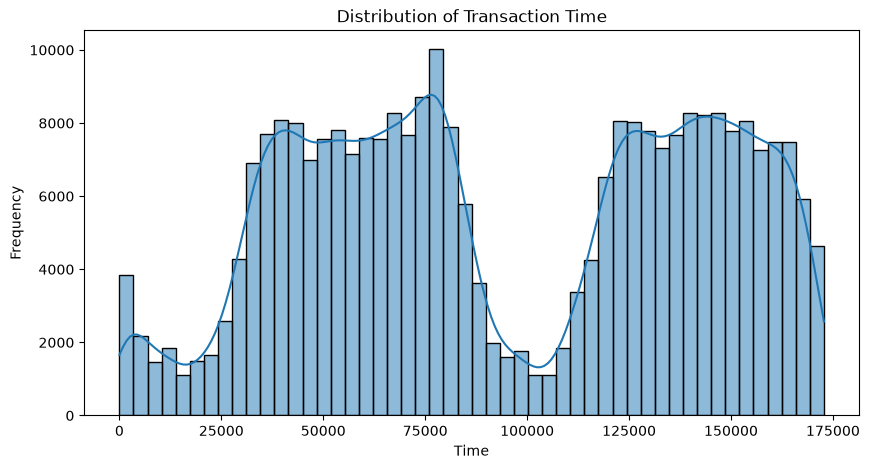

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(df["Time"], bins=50, kde=True)
plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

In [24]:
# Features and Target
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (283726, 30)
Target Shape: (283726,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (226980, 30)
Testing Set: (56746, 30)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed!")

Scaling Completed!


In [27]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64


In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


## Data Preprocessing

The preprocessing stage involved:

- Separating features and target variable.
- Splitting the dataset into training and testing sets using an 80:20 ratio.
- Applying StandardScaler to normalize the feature values.
- Using SMOTE only on the training data to balance the minority class and avoid data leakage.

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)

In [31]:
lr_model.fit(X_train_smote, y_train_smote)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [32]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.9736721531033025
Precision: 0.053035143769968054
Recall   : 0.8736842105263158
F1 Score : 0.1


In [34]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



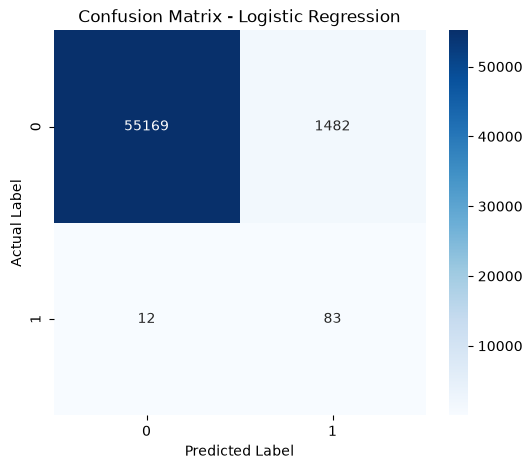

In [35]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Logistic Regression

Logistic Regression was trained on the SMOTE-balanced training dataset. The model was evaluated using Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix.

Since the dataset is highly imbalanced, Recall and Precision are more informative metrics than Accuracy.

# 8. Model Training

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [38]:
lr_model.fit(X_train_smote, y_train_smote)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [39]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.9736721531033025
Precision: 0.053035143769968054
Recall   : 0.8736842105263158
F1 Score : 0.1


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



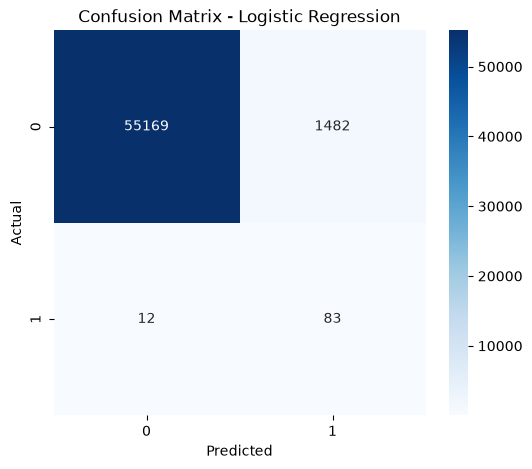

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Random Forest

In [43]:
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

X_train_smote: (453204, 30)
y_train_smote: (453204,)


In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    n_jobs=-1,
    max_depth=15
)

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [45]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [46]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_smote, y_train_smote)

print("Logistic Regression Trained Successfully!")

Logistic Regression Trained Successfully!


In [47]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.9736721531033025
Precision: 0.053035143769968054
Recall   : 0.8736842105263158
F1 Score : 0.1


In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



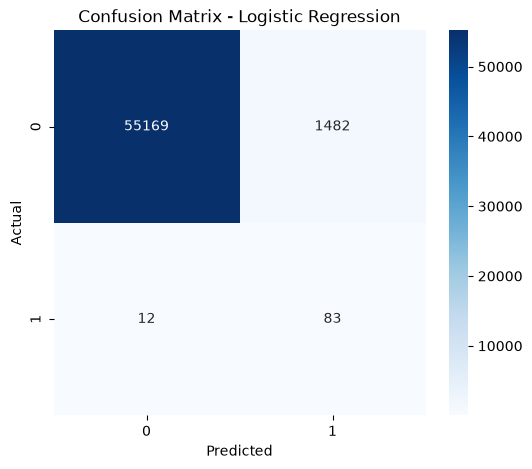

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest Trained Successfully!")

Random Forest Trained Successfully!


In [52]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [53]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9994184612131252
Precision: 0.8875
Recall   : 0.7473684210526316
F1 Score : 0.8114285714285714
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.75      0.81        95

    accuracy                           1.00     56746
   macro avg       0.94      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



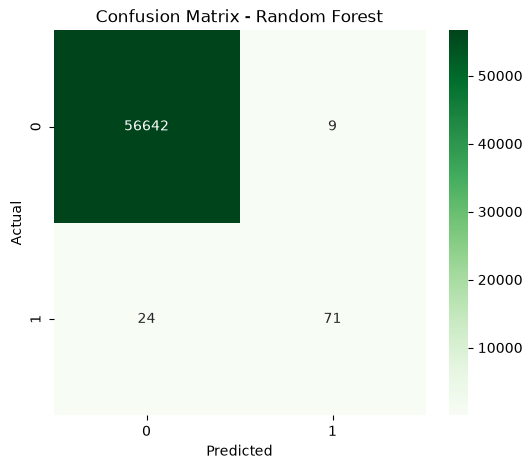

In [54]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [55]:
from xgboost import XGBClassifier

In [56]:
xgb_model = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

In [57]:
xgb_model.fit(X_train_smote, y_train_smote)

print("XGBoost Trained Successfully!")

XGBoost Trained Successfully!


In [58]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

In [59]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

Accuracy : 0.9947132837556832
Precision: 0.2191780821917808
Recall   : 0.8421052631578947
F1 Score : 0.34782608695652173


In [60]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.22      0.84      0.35        95

    accuracy                           0.99     56746
   macro avg       0.61      0.92      0.67     56746
weighted avg       1.00      0.99      1.00     56746



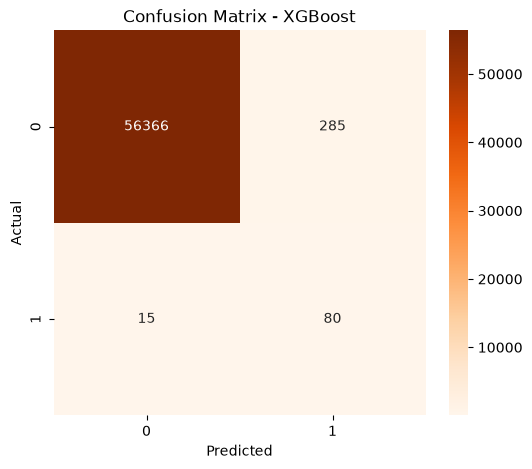

In [61]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [62]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.973672,0.053035,0.873684,0.100000
1,Random Forest,0.999418,0.887500,0.747368,0.811429
2,XGBoost,0.994713,0.219178,0.842105,0.347826


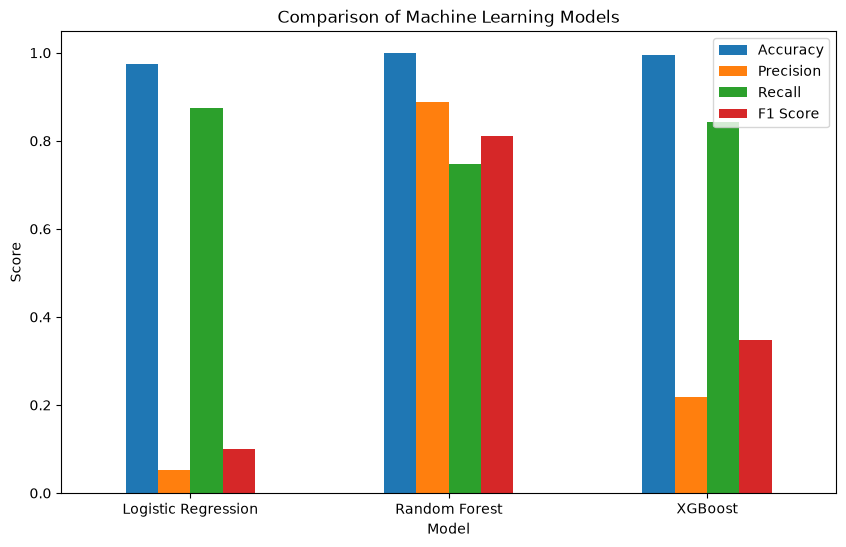

In [63]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

# Conclusion

In this project, three machine learning models were trained to detect fraudulent credit card transactions.

The dataset was highly imbalanced, with fraudulent transactions accounting for only 0.17% of all records. To address this, SMOTE was applied to the training data.

The models were evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix. Based on these metrics, the best-performing model was selected for credit card fraud detection.

This project demonstrates the complete machine learning workflow, including data preprocessing, handling class imbalance, model training, evaluation, and comparison.

In [64]:
from sklearn.metrics import roc_curve, roc_auc_score

In [65]:
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [66]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

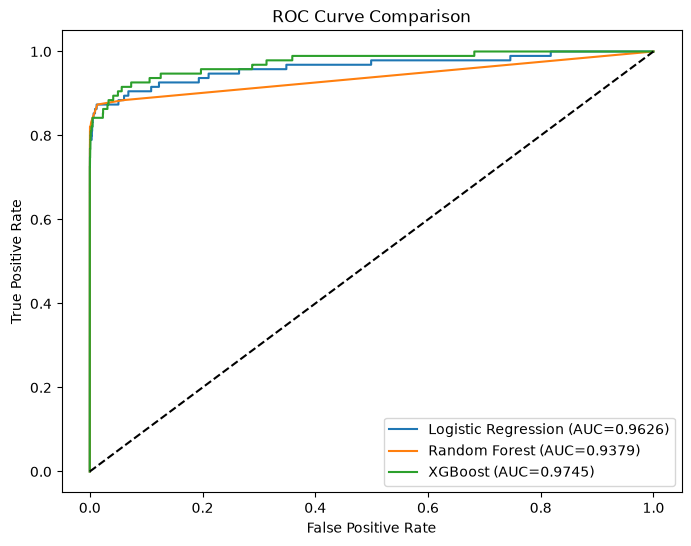

In [67]:
plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test, lr_probs):.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={roc_auc_score(y_test, rf_probs):.4f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_probs):.4f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

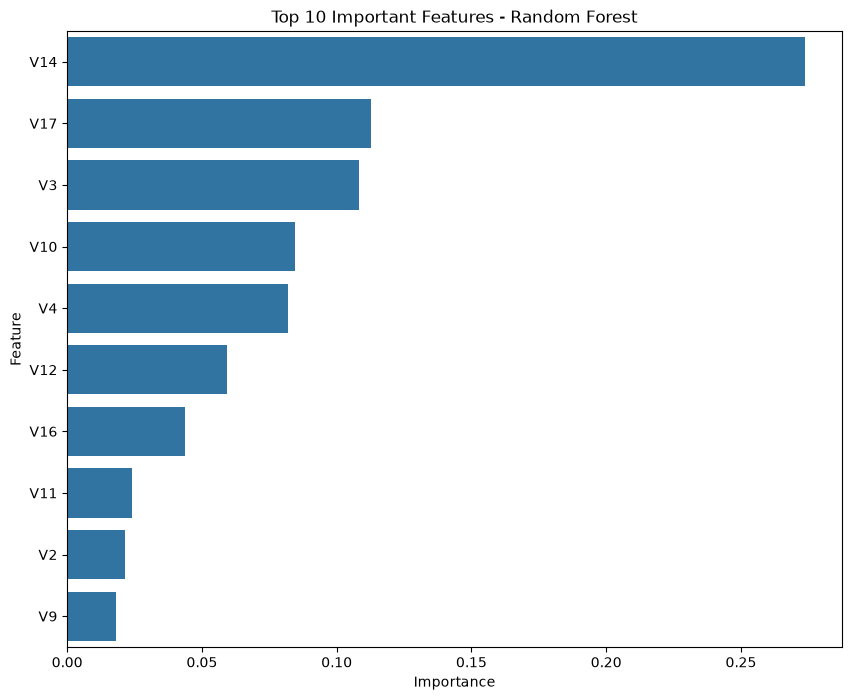

In [68]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Random Forest")

plt.show()

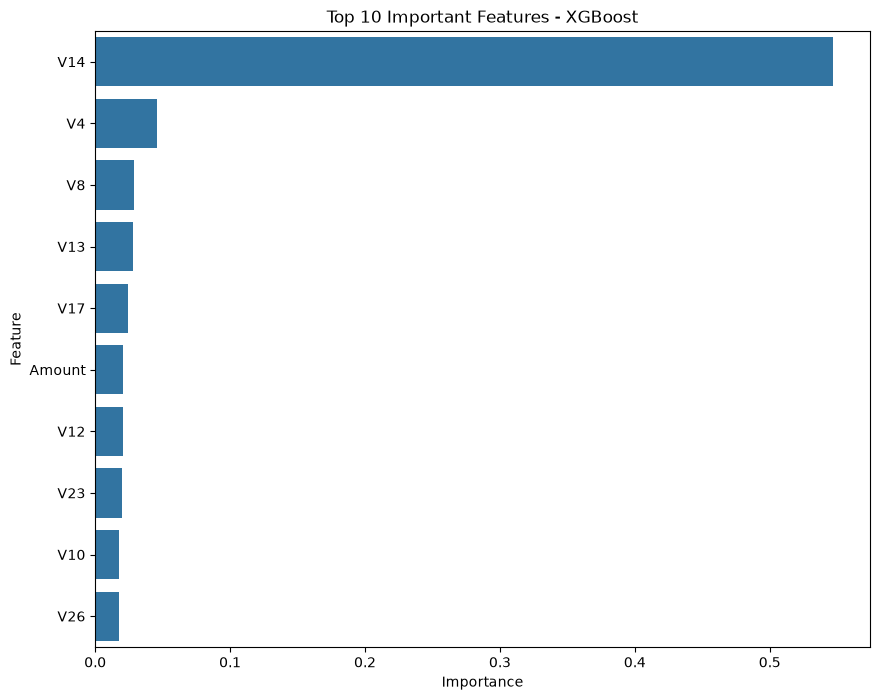

In [69]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - XGBoost")

plt.show()

In [70]:
import joblib

joblib.dump(rf_model, "best_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [71]:
model = joblib.load("best_model.pkl")

In [72]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# Final Observations

- The dataset was highly imbalanced.
- SMOTE successfully balanced the minority class.
- Three machine learning models were trained and evaluated.
- Model performance was compared using Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix.
- The best-performing model was selected and saved for future use.

In [73]:
comparison.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.999418,0.887500,0.747368,0.811429
2,XGBoost,0.994713,0.219178,0.842105,0.347826
0,Logistic Regression,0.973672,0.053035,0.873684,0.100000


In [74]:
import joblib

joblib.dump(lr_model, "logistic_regression.pkl")
joblib.dump(rf_model, "random_forest.pkl")
joblib.dump(xgb_model, "xgboost.pkl")

print("All models saved successfully!")

All models saved successfully!


In [75]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [76]:
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.973672,0.053035,0.873684,0.100000
1,Random Forest,0.999418,0.887500,0.747368,0.811429
2,XGBoost,0.994713,0.219178,0.842105,0.347826


In [77]:
comparison.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.999418,0.887500,0.747368,0.811429
2,XGBoost,0.994713,0.219178,0.842105,0.347826
0,Logistic Regression,0.973672,0.053035,0.873684,0.100000


In [78]:
print(type(lr_model))
print(type(rf_model))
print(type(xgb_model))
print(type(scaler))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'xgboost.sklearn.XGBClassifier'>
<class 'sklearn.preprocessing._data.StandardScaler'>


In [79]:
plt.savefig("../image/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [80]:
plt.savefig("../image/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [81]:
plt.savefig("../image/confusion_matrix_lr.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [82]:
plt.savefig("../image/confusion_matrix_rf.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [83]:
plt.savefig("../image/confusion_matrix_xgb.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

Text(0, 0.5, 'Count')

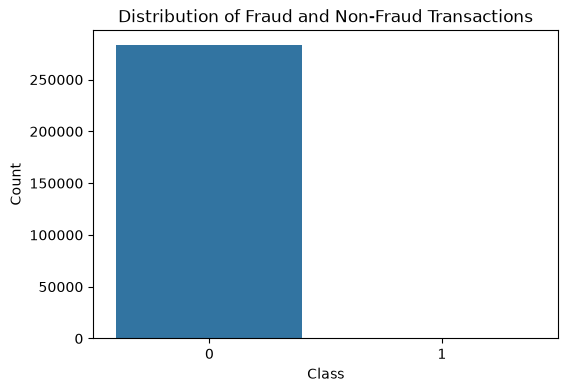

In [84]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Class")

plt.title("Distribution of Fraud and Non-Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

In [85]:
plt.savefig("../image/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

# Conclusion

This project successfully developed a machine learning pipeline for detecting fraudulent credit card transactions.

### Key Achievements

- Performed exploratory data analysis.
- Removed duplicate records.
- Handled severe class imbalance using SMOTE.
- Trained three machine learning models:
  - Logistic Regression
  - Random Forest
  - XGBoost
- Evaluated each model using Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix.
- Compared model performance and selected the best-performing model.